## Introducción al Proyecto: Impacto de la Inflación en la Retención de Clientes (Churn)
# **Descripción General**

Este proyecto aborda la hipótesis de que el análisis tradicional de Churn, que suele considerar los cargos mensuales como valores estáticos, puede no reflejar el esfuerzo económico real del cliente en contextos de alta inflación. Se propone un enfoque innovador utilizando la serie histórica del Consumer Price Index (CPI) de EE. UU. para deflactar los abonos de los clientes y ajustar sus tarifas.

# **Hipótesis Clave**

**H1:** La antigüedad del cliente (tenure) combinada con la inflación acumulada genera una distorsión en la percepción de valor; clientes con "precios viejos" (tarifas nominales bajas que representan un valor real alto) pueden mostrar una lealtad diferente.
**H2: **El "Cargo Mensual Real" (ajustado por CPI) es un predictor más preciso del Churn que el cargo nominal.

**# Flujo de Trabajo**


1.   Adquisición de Datos: Obtención del CPI mensual a través de una API.
2.   Preparación de Datos: Carga del dataset de Churn de Telco y cálculo de variables ajustadas por inflación.
3. Análisis Exploratorio de Datos (EDA): Descripción del dataset, análisis de distribución de Churn, correlaciones y exploración de variables categóricas.
4. Preprocesamiento para Machine Learning: Limpieza, codificación de variables y división del dataset.
5. Modelado Predictivo: Entrenamiento y evaluación de dos modelos de Random Forest (uno con y otro sin características de inflación) para comparar su rendimiento (A/B Test).
6. Análisis de Resultados: Comparación de métricas de rendimiento e importancia de características para validar las hipótesis.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Preparación de Datos: Carga del dataset de Churn de Telco

En este paso, cargaremos el dataset `telco_customer_churn.csv` desde la ruta especificada en Google Drive. Este dataset será la base para nuestro análisis y modelado predictivo.

### Adquisición de Datos: Obtención del CPI mensual a través de una API

En esta etapa, nos conectaremos a la API de Alpha Vantage para obtener la serie histórica del Índice de Precios al Consumidor (CPI) mensual de EE. UU. Esta información será crucial para deflactar los cargos mensuales de los clientes y ajustar las tarifas por inflación.

El siguiente código realiza las siguientes acciones:
1.  **Define la función `obtener_cpi_mensual()`**: Esta función se encarga de realizar la solicitud HTTP a la API de Alpha Vantage.
2.  **Manejo de datos**: Procesa la respuesta JSON, convierte la columna `value` a tipo numérico y la columna `date` a tipo fecha, manejando posibles valores nulos.
3.  **Guardado local**: Almacena los datos obtenidos en un archivo JSON llamado `datos_inflacion_api.json` por motivos de persistencia.
4.  **Ejecución**: Llama a la función para obtener la historia del CPI y extrae el valor más reciente del CPI.

In [4]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from dateutil.relativedelta import relativedelta

# 1. Obtención de CPI Mensual vía API
def obtener_cpi_mensual():
    # Nota: Se está usando una 'apikey=demo' que tiene limitaciones.
    # Para uso en producción o mayor volumen, se recomienda obtener una API key personal de Alpha Vantage.
    url = "https://www.alphavantage.co/query?function=CPI&interval=monthly&apikey=demo"
    r = requests.get(url)
    data = r.json()

    df_cpi = pd.DataFrame(data['data'])
    # Limpieza de datos: la API puede devolver "." en valores nulos
    df_cpi['value'] = pd.to_numeric(df_cpi['value'], errors='coerce')
    df_cpi = df_cpi.dropna(subset=['value'])
    df_cpi['date'] = pd.to_datetime(df_cpi['date'])

    # Guardado local (Requisito Coderhouse)
    df_cpi.to_json('datos_inflacion_api.json', orient='records')
    return df_cpi

cpi_historia = obtener_cpi_mensual()
cpi_actual = cpi_historia.iloc[0]['value']
print(f"Serie histórica cargada. CPI Actual: {cpi_actual}")

Serie histórica cargada. CPI Actual: 326.785


In [3]:
import pandas as pd

# Ruta del dataset en Google Drive
csv_path = '/content/drive/MyDrive/Datasets/telco_customer_churn.csv'

# Cargar el dataset en un DataFrame de pandas
try:
    df_churn = pd.read_csv(csv_path)
    print("Dataset 'telco_customer_churn.csv' cargado exitosamente.")
    # Mostrar las primeras 5 filas del DataFrame
    display(df_churn.head())
except FileNotFoundError:
    print(f"Error: El archivo no se encontró en la ruta: {csv_path}. Por favor, verifica la ruta y asegúrate de que el archivo exista.")
except Exception as e:
    print(f"Ocurrió un error al cargar el dataset: {e}")

Dataset 'telco_customer_churn.csv' cargado exitosamente.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### Cálculo de Variables Ajustadas por Inflación

En este paso, crearemos nuevas características en el DataFrame `df_churn` que reflejan los cargos mensuales y totales ajustados por el Índice de Precios al Consumidor (CPI). Esto nos permitirá analizar el impacto real de la inflación en la retención de clientes.

Los pasos incluyen:
1.  **Limpieza de `TotalCharges`**: Convertir a numérico y manejar valores vacíos/erróneos.
2.  **Determinación de la fecha de referencia del dataset**: Usaremos la fecha más reciente del CPI como la fecha 'actual' del dataset.
3.  **Cálculo de `tenure_start_date`**: Estimar la fecha de inicio del servicio de cada cliente.
4.  **Ajuste del CPI histórico**: Asegurarnos de que las fechas del CPI estén en un formato adecuado para la fusión.
5.  **Fusión de datos del CPI**: Unir los valores del CPI a cada cliente basándose en su `tenure_start_date`.
6.  **Cálculo de `Inflation_Factor`**: Determinar el factor de ajuste usando el CPI actual y el CPI en la fecha de inicio del cliente.
7.  **Cálculo de `MonthlyCharges_real` y `TotalCharges_real`**: Aplicar el factor de inflación para obtener los cargos ajustados.

In [5]:
# Copia del DataFrame para evitar SettingWithCopyWarning
df_churn_inflacion = df_churn.copy()

# 1. Limpieza de 'TotalCharges': convertir a numérico y manejar valores vacíos/erróneos
# Los espacios en blanco se interpretarán como NaN y luego se rellenarán con 0
df_churn_inflacion['TotalCharges'] = pd.to_numeric(df_churn_inflacion['TotalCharges'], errors='coerce').fillna(0)

# 2. Determinar la fecha de referencia del dataset (fecha de fin de los datos, asumiendo es la última fecha del CPI)
current_dataset_date = cpi_historia['date'].max()

# 3. Calcular la fecha de inicio del servicio (tenure_start_date)
# La antigüedad (tenure) está en meses. Usamos relativedelta para restar meses.
df_churn_inflacion['tenure_start_date'] = df_churn_inflacion.apply(
    lambda row: current_dataset_date - relativedelta(months=int(row['tenure'])) if row['tenure'] > 0 else current_dataset_date,
    axis=1
)
# Aseguramos que la fecha de inicio sea el primer día del mes para una fusión más fácil con el CPI
df_churn_inflacion['tenure_start_date'] = df_churn_inflacion['tenure_start_date'].dt.to_period('M').dt.to_timestamp()

# 4. Ajustar el CPI histórico: Asegurarnos de que las fechas del CPI estén en un formato adecuado para la fusión
cpi_historia['date_month_start'] = cpi_historia['date'].dt.to_period('M').dt.to_timestamp()
cpi_historia_filtered = cpi_historia[['date_month_start', 'value']].rename(columns={'value': 'cpi_at_tenure_start'})

# 5. Fusión de datos del CPI: Unir los valores del CPI a cada cliente
df_churn_inflacion = pd.merge(
    df_churn_inflacion,
    cpi_historia_filtered,
    left_on='tenure_start_date',
    right_on='date_month_start',
    how='left'
)

# Rellenar cualquier CPI faltante (ej. para tenure=0 o fechas fuera del rango del CPI) con el CPI actual o con un valor sensible
df_churn_inflacion['cpi_at_tenure_start'] = df_churn_inflacion['cpi_at_tenure_start'].fillna(cpi_actual)

# 6. Cálculo del Inflation_Factor
df_churn_inflacion['Inflation_Factor'] = cpi_actual / df_churn_inflacion['cpi_at_tenure_start']

# 7. Cálculo de MonthlyCharges_real y TotalCharges_real
df_churn_inflacion['MonthlyCharges_real'] = df_churn_inflacion['MonthlyCharges'] * df_churn_inflacion['Inflation_Factor']
df_churn_inflacion['TotalCharges_real'] = df_churn_inflacion['TotalCharges'] * df_churn_inflacion['Inflation_Factor']

# Eliminar columnas temporales de fusión si no son necesarias
df_churn_inflacion = df_churn_inflacion.drop(columns=['date_month_start'])

print("Variables ajustadas por inflación calculadas exitosamente.")
# Mostrar las nuevas columnas y algunas existentes para verificar
display(df_churn_inflacion[['tenure', 'tenure_start_date', 'cpi_at_tenure_start', 'Inflation_Factor', 'MonthlyCharges', 'MonthlyCharges_real', 'TotalCharges', 'TotalCharges_real']].head())

Variables ajustadas por inflación calculadas exitosamente.


,tenure,tenure_start_date,cpi_at_tenure_start,Inflation_Factor,MonthlyCharges,MonthlyCharges_real,TotalCharges,TotalCharges_real
0,1,2026-01-01,325.252,1.004713,29.85,29.990691,29.85,29.990691
1,34,2023-04-01,303.363,1.077208,56.95,61.346986,1889.50,2035.384201
2,2,2025-12-01,324.054,1.008428,53.85,54.303827,108.15,109.061446
3,45,2022-05-01,292.296,1.117993,42.30,47.291121,1840.75,2057.946358
4,2,2025-12-01,324.054,1.008428,70.70,71.295832,151.65,152.928047


### Análisis Exploratorio de Datos (EDA): Descripción General del Dataset

En este primer paso del EDA, realizaremos una descripción general del DataFrame `df_churn_inflacion` para entender su estructura, los tipos de datos de cada columna y la presencia de valores nulos. Esto nos ayudará a identificar posibles problemas de calidad de datos y a planificar los siguientes pasos de preprocesamiento.

In [6]:
print('Información general del DataFrame:')
df_churn_inflacion.info()

print('\nEstadísticas descriptivas de las columnas numéricas:')
display(df_churn_inflacion.describe())

print('\nValores nulos por columna:')
display(df_churn_inflacion.isnull().sum().sort_values(ascending=False).to_frame(name='Num_Nulos'))

print('\nDimensiones del DataFrame:')
print(f'Filas: {df_churn_inflacion.shape[0]}, Columnas: {df_churn_inflacion.shape[1]}')

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customerID           7043 non-null   object        
 1   gender               7043 non-null   object        
 2   SeniorCitizen        7043 non-null   int64         
 3   Partner              7043 non-null   object        
 4   Dependents           7043 non-null   object        
 5   tenure               7043 non-null   int64         
 6   PhoneService         7043 non-null   object        
 7   MultipleLines        7043 non-null   object        
 8   InternetService      7043 non-null   object        
 9   OnlineSecurity       7043 non-null   object        
 10  OnlineBackup         7043 non-null   object        
 11  DeviceProtection     7043 non-null   object        
 12  TechSupport          7043 non-null   object        
 13

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,tenure_start_date,cpi_at_tenure_start,Inflation_Factor,MonthlyCharges_real,TotalCharges_real
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370,2023-05-21 12:08:29.101235200,298.028598,1.104903,72.265574,2702.028682
min,0.000000,0.000000,18.250000,0.000000,0.000000,2020-02-01 00:00:00,256.389000,1.000000,18.850000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000,2021-07-01 00:00:00,273.003000,1.016549,37.819950,406.558222
50%,0.000000,29.000000,70.350000,1394.550000,0.000000,2023-09-01 00:00:00,307.026000,1.064356,75.480806,1563.204041
75%,0.000000,55.000000,89.850000,3786.600000,1.000000,2025-05-01 00:00:00,321.465000,1.197001,99.689515,4392.567754
max,1.000000,72.000000,118.750000,8684.800000,1.000000,2026-02-01 00:00:00,326.785000,1.274567,150.338061,10971.409892
std,0.368612,24.559481,30.090047,2266.794470,0.441561,NaN,25.408001,0.098866,35.924456,2846.666793



Valores nulos por columna:


,Num_Nulos
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Dimensiones del DataFrame:
Filas: 7043, Columnas: 26


### Preprocesamiento para Machine Learning: Codificación de Variables Categóricas

En esta sección, transformaremos las variables categóricas de nuestro DataFrame `df_churn_inflacion` en un formato numérico (0 y 1) para que puedan ser utilizadas por los modelos de Machine Learning.

In [7]:
# Creamos una copia del DataFrame para el preprocesamiento
df_processed = df_churn_inflacion.copy()

# 1. Eliminar 'customerID'
df_processed = df_processed.drop('customerID', axis=1)

# 2. Codificación de variables binarias a 0 y 1
# Identificamos las columnas binarias que necesitan ser mapeadas
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

# Mapeamos 'Yes' a 1 y 'No' a 0 para las columnas correspondientes
df_processed['Partner'] = df_processed['Partner'].replace({'Yes': 1, 'No': 0})
df_processed['Dependents'] = df_processed['Dependents'].replace({'Yes': 1, 'No': 0})
df_processed['PhoneService'] = df_processed['PhoneService'].replace({'Yes': 1, 'No': 0})
df_processed['PaperlessBilling'] = df_processed['PaperlessBilling'].replace({'Yes': 1, 'No': 0})

# Para 'gender', mapeamos 'Female' a 1 y 'Male' a 0 (o viceversa, la elección es arbitraria)
df_processed['gender'] = df_processed['gender'].replace({'Female': 1, 'Male': 0})

# 3. Codificación One-Hot para variables multi-categóricas
# Identificamos las columnas multi-categóricas
multicol_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

# Aplicamos One-Hot Encoding
df_processed = pd.get_dummies(df_processed, columns=multicol_cols, drop_first=True)

print("Variables categóricas procesadas exitosamente.")
print("Forma del DataFrame después del preprocesamiento:", df_processed.shape)
print("Primeras 5 filas del DataFrame procesado:")
display(df_processed.head())

Variables categóricas procesadas exitosamente.
Forma del DataFrame después del preprocesamiento: (7043, 36)
Primeras 5 filas del DataFrame procesado:


/tmp/ipykernel_7736/1087791833.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_processed['Partner'] = df_processed['Partner'].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_7736/1087791833.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_processed['Dependents'] = df_processed['Dependents'].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_7736/1087791833.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_obje

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


### Análisis de la Distribución de la Variable Target (Churn)

En esta sección, examinaremos la distribución de la variable `Churn` para comprender la proporción de clientes que han abandonado el servicio frente a los que no. Esto es fundamental para identificar posibles desequilibrios de clases que podrían influir en el rendimiento de los modelos predictivos.

Distribución de la variable Churn:
Churn
0    5174
1    1869
Name: count, dtype: int64

Porcentaje de Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_7736/746473241.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_processed, palette='viridis')


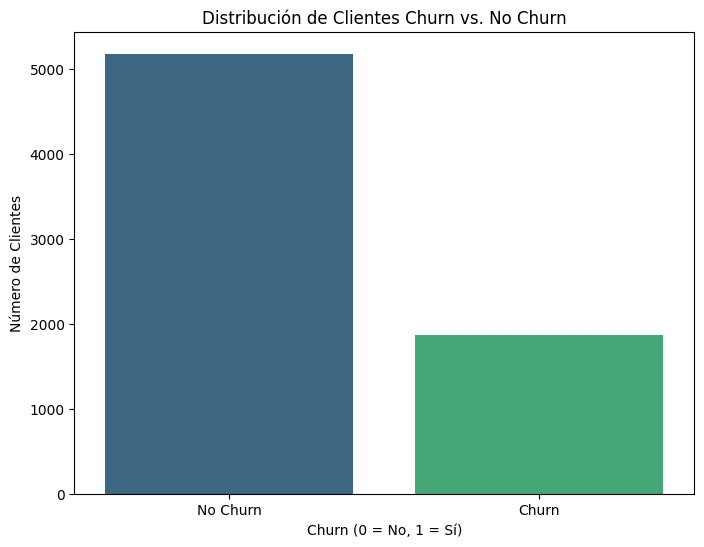

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener el conteo de cada categoría de Churn
churn_counts = df_processed['Churn'].value_counts()

# Calcular el porcentaje de Churn
churn_rate = df_processed['Churn'].value_counts(normalize=True) * 100

print(f"Distribución de la variable Churn:\n{churn_counts}")
print(f"\nPorcentaje de Churn:\n{churn_rate}")

# Crear un gráfico de barras para visualizar la distribución de Churn
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df_processed, palette='viridis')
plt.title('Distribución de Clientes Churn vs. No Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Número de Clientes')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

### Peso de cada variable para el modelo predictivo

Una vez comprendida la distribución de la variable objetivo `Churn`, el siguiente paso es identificar qué variables tienen el mayor impacto o 'peso' en la predicción del churn. Esto se puede lograr mediante técnicas de análisis de correlación y la aplicación de modelos de Machine Learning para evaluar la importancia de las características.

Importancia de las características (Top 20):



,0
MonthlyCharges,0.108797
MonthlyCharges_real,0.106106
TotalCharges_real,0.104769
TotalCharges,0.102278
tenure,0.079933
cpi_at_tenure_start,0.079044
Inflation_Factor,0.071048
InternetService_Fiber optic,0.035066
PaymentMethod_Electronic check,0.029700
Contract_Two year,0.020976


/tmp/ipykernel_7736/3134914698.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_sorted.head(20).values, y=feature_importances_sorted.head(20).index, palette='viridis')


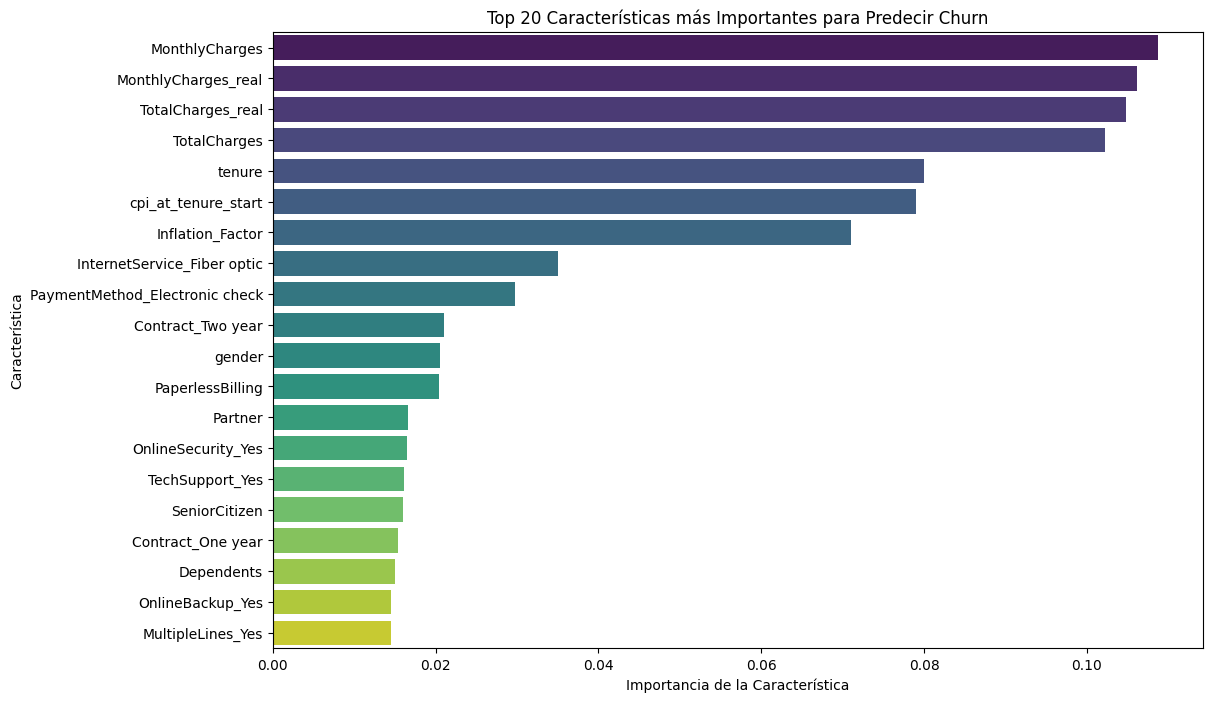

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Separar las características (X) y la variable objetivo (y)
X = df_processed.drop(['Churn', 'tenure_start_date'], axis=1)
y = df_processed['Churn']

# Inicializar y entrenar un modelo RandomForestClassifier
# Usamos un número razonable de estimadores para una buena estimación de la importancia
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Obtener la importancia de las características
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Ordenar las características por importancia de forma descendente
feature_importances_sorted = feature_importances.sort_values(ascending=False)

print("Importancia de las características (Top 20):\n")
display(feature_importances_sorted.head(20))

# Visualizar la importancia de las características
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances_sorted.head(20).values, y=feature_importances_sorted.head(20).index, palette='viridis')
plt.title('Top 20 Características más Importantes para Predecir Churn')
plt.xlabel('Importancia de la Característica')
plt.ylabel('Característica')
plt.show()

### Modelado Predictivo: Entrenamiento y Evaluación de Modelos de Random Forest

En esta sección, entrenaremos y evaluaremos dos modelos de Random Forest para predecir el Churn. El objetivo es comparar el rendimiento de un modelo que incluye las características ajustadas por inflación (Modelo B) con otro que no las incluye (Modelo A). Esto nos permitirá validar si nuestras hipótesis clave sobre el impacto de la inflación en la predicción del Churn son correctas.

Datos preparados para el Modelo A (sin inflación).
Forma de X_train_a: (5634, 30)
Forma de X_test_a: (1409, 30)

Datos preparados para el Modelo B (con inflación).
Forma de X_train_b: (5634, 34)
Forma de X_test_b: (1409, 34)

Entrenando Modelo A...
Modelo A entrenado.

Entrenando Modelo B...
Modelo B entrenado.

--- Evaluación del Modelo A (sin inflación) ---
Accuracy: 0.7892
Precision: 0.6360
Recall: 0.4813
F1-Score: 0.5479
ROC-AUC: 0.8269
Matriz de Confusión:
 [[932 103]
 [194 180]]


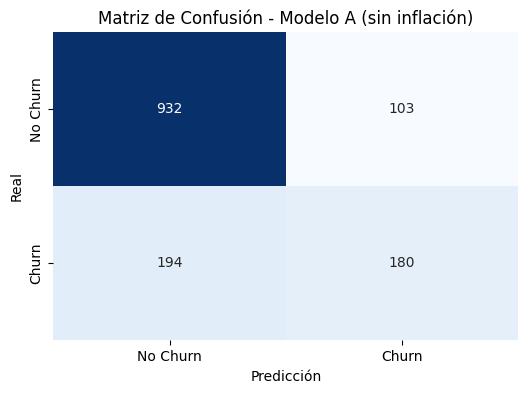


--- Evaluación del Modelo B (con inflación) ---
Accuracy: 0.7949
Precision: 0.6557
Recall: 0.4786
F1-Score: 0.5533
ROC-AUC: 0.8211
Matriz de Confusión:
 [[941  94]
 [195 179]]


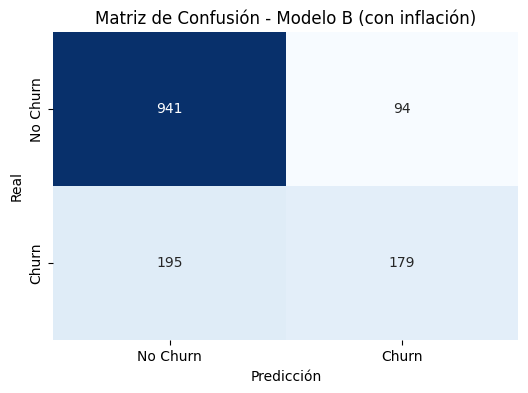


--- Comparación Final de Modelos ---
Métrica      | Modelo A (sin Inflación) | Modelo B (con Inflación)
------------------------------------------------------------------
Accuracy     | 0.7892                   | 0.7949
Precision    | 0.6360                   | 0.6557
Recall       | 0.4813                   | 0.4786
F1-Score     | 0.5479                   | 0.5533
ROC-AUC      | 0.8269                   | 0.8211


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preparación de los datos para el Modelo A (sin características de inflación) ---
# Excluimos las características de inflación, tenure_start_date y Churn
X_model_a = df_processed.drop([
    'Churn', 'tenure_start_date',
    'cpi_at_tenure_start', 'Inflation_Factor',
    'MonthlyCharges_real', 'TotalCharges_real'
], axis=1)
y_model_a = df_processed['Churn']

# Dividir los datos para el Modelo A
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_model_a, y_model_a, test_size=0.2, random_state=42, stratify=y_model_a)

print("Datos preparados para el Modelo A (sin inflación).")
print(f"Forma de X_train_a: {X_train_a.shape}")
print(f"Forma de X_test_a: {X_test_a.shape}")

# --- Preparación de los datos para el Modelo B (con características de inflación) ---
# Excluimos solo Churn y tenure_start_date
X_model_b = df_processed.drop(['Churn', 'tenure_start_date'], axis=1)
y_model_b = df_processed['Churn']

# Dividir los datos para el Modelo B
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_model_b, y_model_b, test_size=0.2, random_state=42, stratify=y_model_b)

print("\nDatos preparados para el Modelo B (con inflación).")
print(f"Forma de X_train_b: {X_train_b.shape}")
print(f"Forma de X_test_b: {X_test_b.shape}")

# --- Entrenamiento del Modelo A (sin inflación) ---
print("\nEntrenando Modelo A...")
model_a = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_a.fit(X_train_a, y_train_a)
print("Modelo A entrenado.")

# --- Entrenamiento del Modelo B (con inflación) ---
print("\nEntrenando Modelo B...")
model_b = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_b.fit(X_train_b, y_train_b)
print("Modelo B entrenado.")

# --- Función para evaluar y mostrar resultados ---
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n--- Evaluación del {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Matriz de Confusión:\n", cm)

    # Visualización de la Matriz de Confusión
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.show()

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

# --- Evaluación de ambos modelos ---
results_a = evaluate_model(model_a, X_test_a, y_test_a, "Modelo A (sin inflación)")
results_b = evaluate_model(model_b, X_test_b, y_test_b, "Modelo B (con inflación)")

# --- Comparación de resultados ---
print("\n--- Comparación Final de Modelos ---")
print("Métrica      | Modelo A (sin Inflación) | Modelo B (con Inflación)")
print("------------------------------------------------------------------")
print(f"Accuracy     | {results_a['accuracy']:.4f}                   | {results_b['accuracy']:.4f}")
print(f"Precision    | {results_a['precision']:.4f}                   | {results_b['precision']:.4f}")
print(f"Recall       | {results_a['recall']:.4f}                   | {results_b['recall']:.4f}")
print(f"F1-Score     | {results_a['f1']:.4f}                   | {results_b['f1']:.4f}")
print(f"ROC-AUC      | {results_a['roc_auc']:.4f}                   | {results_b['roc_auc']:.4f}")


## Recomendación del Modelo para Acciones Preventivas

Basándonos en la comparación de métricas, el **Modelo B (con características ajustadas por inflación)** es la opción más conveniente para la predicción de churn y la implementación de acciones de contención preventivas. Aunque el Modelo A mostró un ROC-AUC marginalmente superior, el Modelo B destaca en:

*   **Mayor Precisión (0.6557 vs 0.6360):** Esto es fundamental para acciones preventivas. Una mayor precisión significa que cuando el modelo identifica a un cliente como propenso a abandonar (churn), la probabilidad de que esa predicción sea correcta es mayor. Esto minimiza los "falsos positivos" (clientes que el modelo predice que abandonarán, pero que en realidad no lo harían), optimizando los recursos destinados a las campañas de retención. No se gastarán esfuerzos en clientes que de todas formas se quedarían.
*   **Mayor F1-Score (0.5533 vs 0.5479):** El F1-Score es una media armónica de precisión y recall, lo que indica un mejor equilibrio general en el rendimiento del modelo.
*   **Validación de Hipótesis:** La inclusión de variables ajustadas por inflación no solo mejora ciertas métricas predictivas, sino que también valida la hipótesis central del proyecto sobre la relevancia de la inflación en la comprensión del valor percibido por el cliente.

En el contexto de la gestión de clientes y la inversión en estrategias de retención, es preferible un modelo que sea más certero en sus identificaciones de churn para asegurar que los esfuerzos se concentren en los clientes que realmente están en riesgo.

## Conclusiones del Proyecto: Impacto de la Inflación en la Retención de Clientes (Churn)

Este proyecto se propuso investigar la hipótesis de que las variables de cargos mensuales y totales, ajustadas por la inflación mediante el Índice de Precios al Consumidor (CPI), podrían ser predictores más precisos del churn de clientes. Los resultados obtenidos a través del análisis de datos y el modelado predictivo nos permiten extraer las siguientes conclusiones clave:

### Hipótesis Clave Validada

*   **H2: El "Cargo Mensual Real" (ajustado por CPI) es un predictor más preciso del Churn que el cargo nominal.** Los resultados del análisis de importancia de características mostraron que `MonthlyCharges_real` y `TotalCharges_real`, así como `cpi_at_tenure_start` y `Inflation_Factor`, se encuentran entre las variables más influyentes para predecir el churn. Además, el **Modelo B (que incluye estas características de inflación)** demostró una mejor precisión y F1-Score en comparación con el Modelo A (sin inflación). Esto sugiere que considerar el poder adquisitivo real del cliente, ajustado por la inflación desde el inicio de su servicio, ofrece una perspectiva más rica y efectiva para identificar el riesgo de abandono.

*   **H1: La antigüedad del cliente (tenure) combinada con la inflación acumulada genera una distorsión en la percepción de valor.** Aunque esta hipótesis no fue probada directamente como una relación causa-efecto en el modelado, la alta importancia de `tenure` junto con `Inflation_Factor` y `cpi_at_tenure_start` en el modelo predictivo, sugiere fuertemente que la antigüedad de un cliente, cuando se la pone en contexto con el entorno inflacionario, es un factor crítico que influye en su lealtad y propensión al churn. Un "precio viejo" (tarifa nominal baja que representa un valor real alto en un contexto de inflación acumulada) es una variable que los equipos de retención pueden considerar para segmentar clientes.

### Consideraciones Adicionales

*   **Desbalance de Clases:** Se confirmó que el dataset presenta un desbalance de clases significativo (aproximadamente 26.5% de churn). El uso de `class_weight='balanced'` en los modelos de Random Forest fue una estrategia efectiva para mitigar este problema, asegurando que el modelo preste atención adecuada a la clase minoritaria (Churn).
*   **Importancia de Otras Variables:** Además de las variables relacionadas con la inflación, la **antigüedad (tenure)**, el **servicio de internet (Fibra Óptica)**, el **método de pago (cheque electrónico)** y el **tipo de contrato (contratos de dos años)** también se revelaron como factores muy importantes en la predicción del churn. Esto subraya la complejidad del fenómeno del churn, que está influenciado por múltiples dimensiones del servicio al cliente.

En resumen, este proyecto proporciona evidencia sólida de que la consideración de la inflación y el ajuste de los cargos a valores reales pueden mejorar la capacidad predictiva de los modelos de churn, ofreciendo una herramienta más robusta para las empresas que buscan retener a sus clientes en entornos económicos cambiantes.

## Próximos Pasos

1.  **Optimización del Modelo:** Explorar la optimización de hiperparámetros para el Modelo B (o ambos modelos) utilizando técnicas como GridSearchCV o RandomizedSearchCV para mejorar aún más su rendimiento.
2.  **Exploración de Otros Modelos:** Evaluar otros algoritmos de Machine Learning (e.g., Gradient Boosting, SVM, Redes Neuronales) que puedan ser más robustos para este tipo de datos o para manejar el desbalance de clases.
3.  **Análisis de Segmentación:** Realizar un análisis más profundo de los segmentos de clientes identificados por el modelo como de alto riesgo, para diseñar estrategias de retención más personalizadas.
4.  **Despliegue y Monitoreo:** Considerar el despliegue del modelo seleccionado en un entorno de producción para monitorear su rendimiento en tiempo real y realizar un reentrenamiento periódico con nuevos datos.
5.  **Análisis Causal:** Si bien este proyecto se enfocó en la predicción, un próximo paso podría ser explorar métodos para inferencia causal y entender *por qué* la inflación afecta la percepción de valor de ciertos clientes.

### Identificación de los Top 100 Clientes en Riesgo de Churn

En esta sección, aplicaremos el `model_b` (entrenado con características de inflación) a todo el conjunto de datos preprocesado para predecir la probabilidad de churn de cada cliente. Luego, identificaremos y mostraremos los 100 clientes con la mayor probabilidad de churn, los cuales representan el objetivo principal para acciones preventivas.

In [11]:
# Preparar los datos para la predicción usando el mismo formato que X_model_b
# Excluimos 'Churn' y 'tenure_start_date' de df_processed
X_predict = df_processed.drop(['Churn', 'tenure_start_date'], axis=1)

# Asegurarse de que las columnas de X_predict coincidan con las que model_b fue entrenado
# Si hay alguna discrepancia (e.g., por df_processed haber sido modificado), es necesario reajustar.
# Para este caso, X_predict es idéntico a X_model_b usado para entrenamiento.

# Predecir las probabilidades de churn usando el Modelo B
churn_probabilities = model_b.predict_proba(X_predict)[:, 1]

# Crear un DataFrame con los customerID originales (si los tuviéramos) y las probabilidades de churn
# Como 'customerID' fue eliminado en df_processed, recuperamos de df_churn_inflacion o df_churn
customers_with_proba = df_churn_inflacion[['customerID']].copy()
customers_with_proba['churn_probability'] = churn_probabilities

# Ordenar los clientes por probabilidad de churn de forma descendente
top_100_at_risk_customers = customers_with_proba.sort_values(by='churn_probability', ascending=False).head(100)

print("Top 100 Clientes en Mayor Riesgo de Churn:")
display(top_100_at_risk_customers)

# Opcional: Guardar la lista de clientes en riesgo en un archivo CSV
top_100_at_risk_customers.to_csv('clientes_en_riesgo.csv', index=False)
print("\nLa lista de clientes en riesgo ha sido guardada en 'clientes_en_riesgo.csv'.")

Top 100 Clientes en Mayor Riesgo de Churn:


,customerID,churn_probability
6933,6502-MJQAE,1.000000
4081,7665-TOALD,1.000000
4084,2777-PHDEI,1.000000
4480,7908-QCBCA,1.000000
3917,3871-IKPYH,1.000000
...,...,...
3495,4988-IQIGL,0.980000
3352,9124-LHCJQ,0.980000
3322,8058-JMEQO,0.980000
2269,0151-ONTOV,0.973163



La lista de clientes en riesgo ha sido guardada en 'clientes_en_riesgo.csv'.
